In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
from util import calculate_pass_at_k

In [3]:
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [4]:
with open('/u/rfechner/data/verified_at_k/chats-out.parquet', 'rb') as file:
    df = pd.read_parquet(file)

In [5]:
df

,prompt,method,old_index,responses
158,[{'content': 'You are a helpful judge and an e...,base,158,"[<think>\nOkay, let's see. The task is to dete..."
83,[{'content': 'You are a helpful judge and an e...,base,83,"[<think>\nOkay, let's see. The task is to dete..."
170,[{'content': 'You are a helpful judge and an e...,base,170,"[<think>\nOkay, let's see. The question is ask..."
101,[{'content': 'You are a helpful judge and an e...,base,101,"[<think>\nOkay, let's see. The question is abo..."
150,[{'content': 'You are a helpful judge and an e...,base,150,"[<think>\nOkay, let's see. The task is to dete..."
...,...,...,...,...
161239,[{'content': 'You are a helpful judge and an e...,gspo,161239,"[<think>\nOkay, let's look at the student's an..."
161244,[{'content': 'You are a helpful judge and an e...,gspo,161244,"[<think>\nOkay, let's see. The user wants me t..."
161133,[{'content': 'You are a helpful judge and an e...,gspo,161133,"[<think>\nOkay, let's see. The task is to dete..."
161142,[{'content': 'You are a helpful judge and an e...,gspo,161142,"[<think>\nOkay, let's see. The task is to dete..."


In [26]:
df.iloc[0]['prompt']

array([{'content': 'You are a helpful judge and an expert in mathematical reasoning.', 'role': 'system'},
       {'content': "You're given a question and a students answer. Answer '#### yes' if and only if the answer contains explicit (verbalized) verification of any intermediate or the final result - no matter whether the answer is correct. This includes explicit re-iterating over answers to check their correctness, verification by plugging in the found result back into the equation to check the answer satisfies conditions etc. This may include student answers which contain 'Let's verify the answer' or 'Let's check the answer' etc.\nHowever, this does not include step-by-step initial solution of the problem, we're only looking for verbalized verification after a solution was already computed. Do not attempt to solve the question yourself, simply return whether the answer contains any verification matching the previous description.Answer '#### no' if the answer doesn't contain verifica

In [21]:
def parse(response : list[str]):
    r = response[0]
    if len(r) <= 10: # deprecated answer
        return 0
    tail = r[-10:]
    try:
        ans_index = tail.rindex('#### ')
    except:
        return 0
    if 'Python' in response[0]:
        return 0
    return 'yes' in tail[ans_index:]

In [30]:
def question_from_prompt(x : list[dict]):
    inp = x[1]['content']
    qindex, sindex = inp.rindex('\n\n\nQuestion'), inp.rindex("\n\nStudent's correct answer:")
    return inp[qindex : sindex]

df['reward'] = df['responses'].apply(parse)
df['input'] = df['prompt'].apply(question_from_prompt)

In [32]:
import numpy as np
plotting_values = {}
for method, dff in df.groupby('method', sort=False):
    plotting_values[method] = calculate_pass_at_k(dff, ks=2 ** np.arange(5))
    

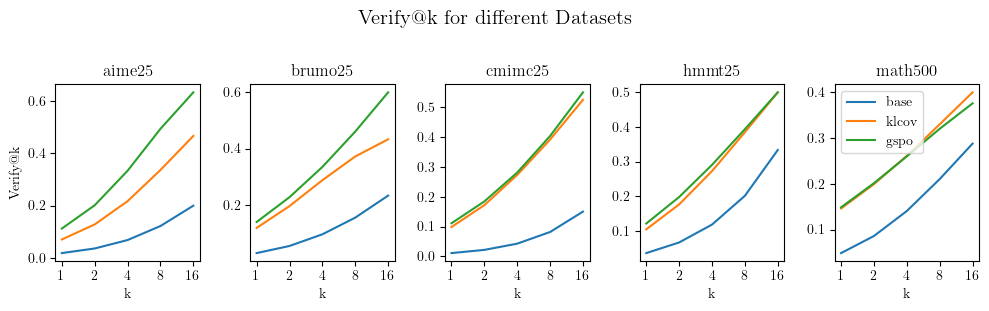

In [49]:
dataset_names = sorted(list(plotting_values['base'].keys()))
fig, axes = plt.subplots(nrows=1, ncols=len(dataset_names), figsize=(2*len(dataset_names), 3))

for ax, name in zip(axes.flatten(), dataset_names):
    
    for k, v in plotting_values.items():
        vs = v[name].mean(axis=0)
        ax.plot(vs, label=k)
    ax.set_title(name)
    ax.set_xticks(np.arange(len(vs)), 2**np.arange(len(vs)))
    ax.set_xlabel('k')
axes[0].set_ylabel('Verify@k')
plt.suptitle('Verify@k for different Datasets', y=1.02, fontsize=15)
plt.tight_layout()
plt.legend()
plt.show()